(example_ismi_binary_classification_example)=

# Inter-Site Matched Interpolation (ISMI) - Multisite Harmonization Example

This notebook demonstrates the use of `InterSiteMatchedInterpolation` for harmonizing multi-site neuroimaging data.

Unlike [Intra-Site Interpolation (ISI)](#intra_site_interpolation) which balances classes within each site independently, ISMI creates synthetic samples by interpolating 
between matched subjects across different sites, reducing site-related confounds while preserving biological signal.

## Setup and Imports


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# UniHarmony imports
from uniharmony import make_multisite_classification, verbosity
from uniharmony.interpolation import InterSiteMatchedInterpolation


verbosity("warning")
sns.set_theme(style="whitegrid")

## Generate Synthetic Multi-Site Data

We create a dataset with 3 sites, simulating a scenario where:
- Site A: Younger population, slight class imbalance
- Site B: Older population, different feature distribution
- Site C: Mixed population, different acquisition protocol

In [2]:
# Generate base dataset
X, y, sites = make_multisite_classification(n_samples=600, n_features=2, n_classes=2, n_sites=3, balance_per_site=[0.2, 0.5, 0.8])

# Simulate site-specific age and sex covariates for matching
site_names = np.unique(sites)
n_per_site = len(X) // len(site_names)

ages = np.concatenate(
    [
        np.random.normal(50, 20, n_per_site),  # Site A: young
        np.random.normal(50, 20, n_per_site),  # Site B: old
        np.random.normal(50, 20, n_per_site),  # Site C: mixed
    ]
)

sex = np.concatenate(
    [
        np.random.choice(["M", "F"], n_per_site, p=[0.9, 0.1]),  # Site A: male-biased
        np.random.choice(["M", "F"], n_per_site, p=[0.5, 0.5]),  # Site B: balanced
        np.random.choice(["M", "F"], n_per_site, p=[0.1, 0.9]),  # Site C: female-biased
    ]
)

# Reshape for the interpolator
categorical_covariate = sex.reshape(-1, 1)
continuous_covariate = ages.reshape(-1, 1)

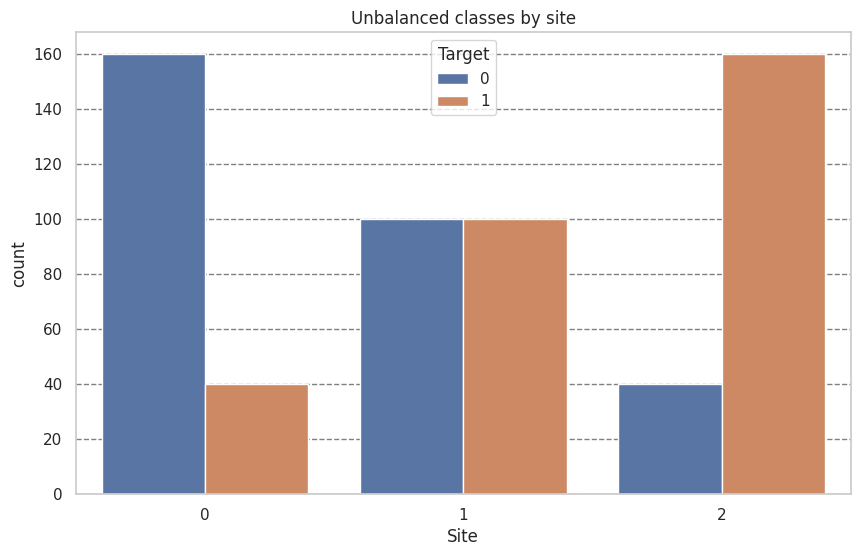

In [3]:
df = pd.DataFrame({"Target": y, "Site": sites})

plt.figure(figsize=[10, 6])
plt.title("Unbalanced classes by site")
sns.countplot(df, x="Site", hue="Target")
plt.grid(axis="y", color="black", alpha=0.5, linestyle="--")

## Apply Inter-Site Matched Interpolation (ISMI)

We use ISMI with the following configuration:
- **Mode**: pairwise (all site combinations)
- **Matching**: Age (±5 years tolerance) and Sex (exact match)
- **Alpha**: 0.3 (constant) - keeps synthetic samples closer to base site
- **k**: 2 (generate 2 synthetic samples per match)

In [4]:
# Configure ISMI
ismi = InterSiteMatchedInterpolation(
    covariate_tolerance=5,  # tolerance for age
    concatenate=False,
)

# Apply interpolation
X_ismi, y_ismi = ismi.fit_resample(
    X, y, sites=sites, categorical_covariate=categorical_covariate, continuous_covariate=continuous_covariate
)
# To maintain compatibility with sklearn and imlearn, sites are stored as attributes
sites_ismi = ismi.sites_resampled_

## Visualize Harmonized Data

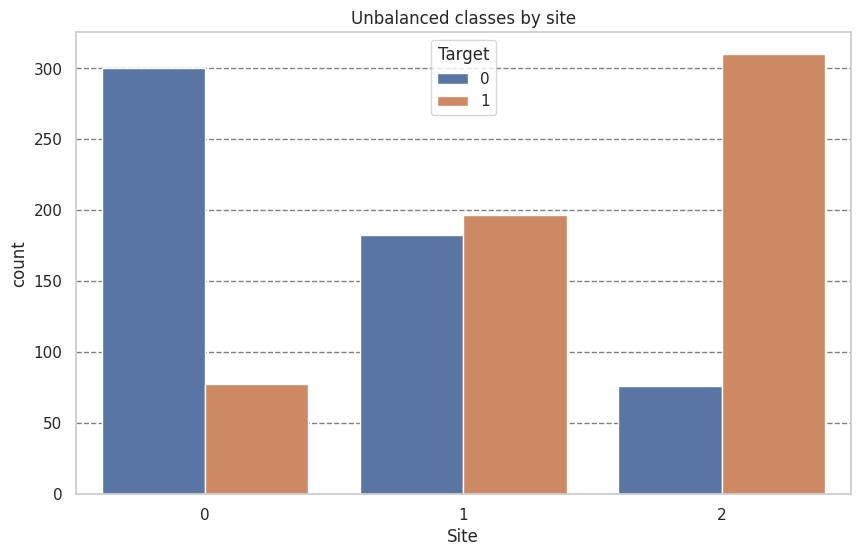

In [5]:
df = pd.DataFrame({"Target": y_ismi, "Site": sites_ismi})

plt.figure(figsize=[10, 6])
plt.title("Unbalanced classes by site")
sns.countplot(df, x="Site", hue="Target")
plt.grid(axis="y", color="black", alpha=0.5, linestyle="--")

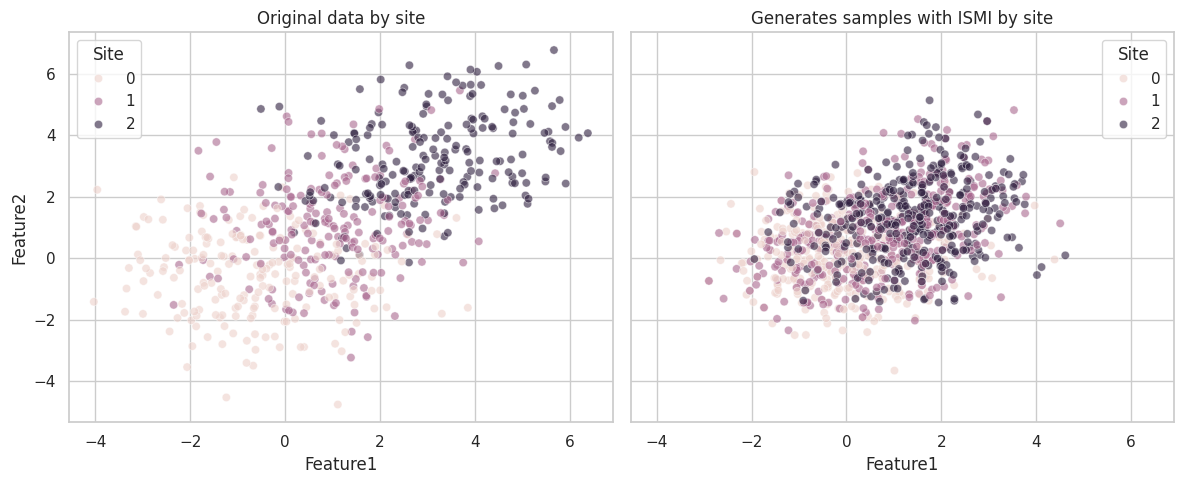

In [6]:
df_orig = pd.DataFrame(X, columns=["Feature1", "Feature2"])
df_orig["Site"] = sites
df_orig["Phase"] = "Original"

df_harm = pd.DataFrame(X_ismi, columns=["Feature1", "Feature2"])
df_harm["Site"] = sites_ismi
df_harm["Phase"] = "Harmonized"

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
sns.scatterplot(data=df_orig, x="Feature1", y="Feature2", hue="Site", alpha=0.6, ax=axes[0])
axes[0].set_title("Original data by site")
sns.scatterplot(data=df_harm, x="Feature1", y="Feature2", hue="Site", alpha=0.6, ax=axes[1])
axes[1].set_title("Generates samples with ISMI by site")
plt.tight_layout()

## Key Takeaways

This evaluation correctly measures whether ISMI helps the model learn 
site-invariant features that generalize to new, unseen sites.

## Conclusion

This notebook demonstrated `InterSiteMatchedInterpolation` for multi-site 
harmonization. Key findings:

1. **ISMI generates synthetic samples** by interpolating between matched subjects 
   across sites, using covariates (age, sex) to ensure biological plausibility.

2. **Alpha reversal** efficiently handles bidirectional interpolation without 
   redundant matching (Site A→B with α, Site B→A with 1-α).

3. **Configuration options** (k, alpha, mode) allow flexible control over the 
   harmonization process.

4. **Unmatched samples tracking** helps identify site pairs with poor overlap.

For real neuroimaging data, ISMI can help reduce site-related confounds while 
presaging biological signals relevant to the target variable.